# Chapter 6: Database Design Using the E-R Model


## Core Question

Before creating tables, how can we derive entities, attributes, relationships, and
constraints from user requirements, and then map the conceptual design to relational
schemas with keys and foreign keys?


## Teaching Summary

| Topic | Worked example and practice | Evidence to retain |
|---|---|---|
| Requirements, entities, attributes, relationships, and keys | Course-registration business rules | Initial E-R diagram |
| Cardinality, participation, weak entities, and design choices | Compare designs against requirements | Annotated diagram |
| Redundancy removal and relational mapping | Map the diagram to relations | Revised diagram and schema |

Extended E-R features and alternative notations are extensions, not major Exam 2 topics.

Before checking the mapped schema, predict which sample rows should succeed or fail and
which derived values the query should return. Compare those predictions with the
observed constraints and query results.


## Connection to Other Chapters

Chapters 2-5 used an existing schema. The E-R model appears earlier in the design process:
requirements are converted to a conceptual design before relations are created. Chapter
7 then checks relational designs for functional dependencies and anomalies.


## Prerequisites

- Identify facts and rules in a short requirement statement.
- Identify primary, candidate, foreign, and composite keys.
- Read a basic schema diagram and distinguish a schema from its current data.


## Case Files

- `course_registration_rules.md`: requirements and questions.
- `course_registration_er.svg` and `.png`: conceptual E-R diagram.
- the mapped-schema SQL cell: mapped SQLite schema and sample data.

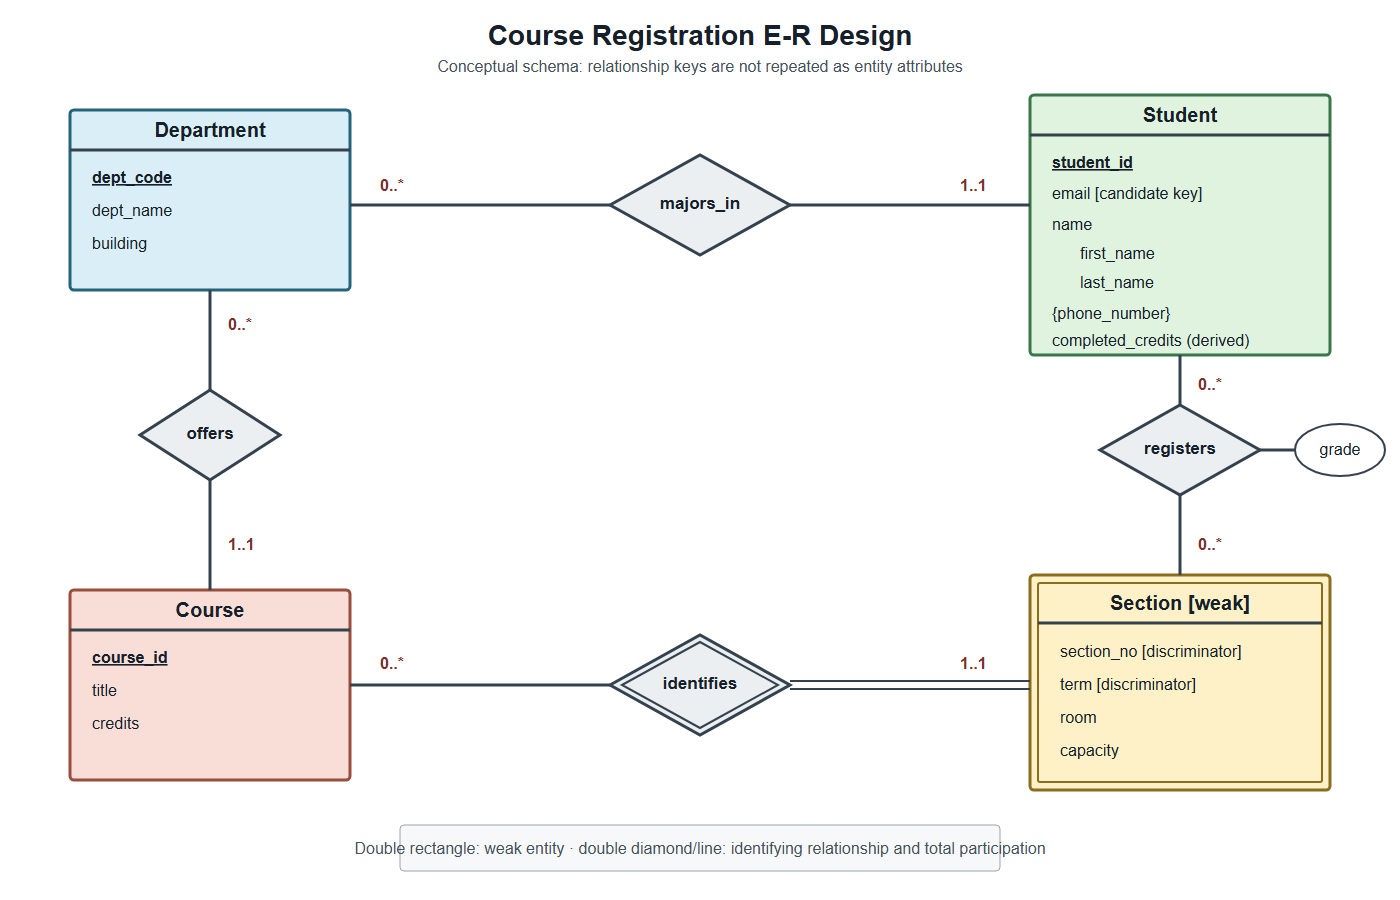

The diagram uses rectangles for entities, diamonds for relationships, and `min..max`
cardinality. E-R notation is not universal. Always confirm a tool's legend before
interpreting where a number or marker applies.


## Learning Objectives

After completing this chapter, you should be able to:

1. Distinguish requirements, conceptual, logical, and physical design outputs.
2. Identify entity sets, attributes, relationships, and roles from business rules.
3. Classify simple, composite, multivalued, and derived attributes.
4. Determine cardinality and participation in both directions.
5. Select keys for entities and relationships.
6. Identify an owner, discriminator, and identifying relationship for a weak entity.
7. Remove conceptually redundant key attributes.
8. Map entities, complex attributes, weak entities, and relationships to relations.
9. Support a design choice with requirement evidence.


## 1. Design Stages

| Stage | Main question | Case output |
|---|---|---|
| Requirements | What facts and rules must be retained? | Rules document |
| Conceptual design | What entities, attributes, relationships, and constraints exist? | E-R diagram |
| Logical design | How are they represented by relational schemas? | Table definitions in the mapped-schema SQL cell |
| Physical design | How should data be stored and accessed? | Index decisions in Chapter 14 |

### Worked Example

Requirement: a Course may have zero or more Sections; each Section belongs to exactly one
Course. The conceptual model creates Course, Section, and an identifying relationship.
The logical mapping later places `course_id` in the Section relation as a key component
and foreign key. An index is not a conceptual-design answer.

### Practice

Place the rule "grade must be an allowed code" in the design process. The conceptual
model records the data rule; the logical schema may implement it with a nullable `CHECK`.


## 2. Redundancy and Incompleteness

A poor design may store the same fact repeatedly or make a valid fact impossible to store
independently.

If one relation contains
`section(course_id, title, credits, term, section_no)`, course title and credits repeat in
every section. A course with no section cannot be stored naturally. Separate Course and
Section entities connected by a relationship solve both problems.

Practice: inspect
`student_registration(student_id, student_name, course_id, course_title, grade)`. Identify
two repeated facts and one valid fact that cannot be stored independently. "The table is
large" is not an explanation.


## 3. Entities and Attributes

An **entity** is a distinguishable object. An **entity set** collects similar entities.
An **attribute** describes an entity.

S101 is a Student entity; Student is the entity set. `student_id`, email, and name are
attributes. A current collection of Student entities is not the same as the entity-set
definition.

### Complex Attributes

- A composite attribute has meaningful components, such as first and last name.
- A multivalued attribute has several values for one entity, such as phone numbers.
- A derived attribute is calculated from other data, such as completed credits.
- A simple, single-valued attribute has one value treated as indivisible.

If phone numbers need their own type, location, ownership, or relationships, model Phone
as an entity. If only several numbers are needed, a multivalued attribute may be enough.

`NULL` may indicate missing, unknown, or not applicable information. These meanings are
not interchangeable. In this case, a `NULL` grade means not graded yet, not zero.


## 4. Relationships, Roles, and Degree

A relationship associates entities and may have descriptive attributes. Its degree is
the number of participating entity sets.

S101 registering for Section DB201/115-1/1 is one instance of the binary `registers`
relationship. Grade belongs to that Student-Section relationship.

A Course-prerequisite relationship is recursive: Course participates twice with
different roles. Use names such as `course_id` and `prereq_id` to avoid ambiguity.

A relationship among Instructor, Student, and Project is ternary if the complete triple
must be retained. Replacing it with unrelated binary pairs may lose which instructor
guided which student on which project.


## 5. Cardinality and Participation

Ask both directions separately:

1. For one A entity, how many B entities may be related?
2. For one B entity, how many A entities may be related?

For Department-Student, one Department may have zero or many Students, while each Student
has exactly one major Department. This is one-to-many from Department to Student.

Minimum cardinality states whether participation is required. A Student with exactly one
major has `1..1`; a Department that may have no Student has `0..*`.

### Policy Change Practice

If a new student may be temporarily undeclared, Student participation changes from
`1..1` to `0..1`. In the relational mapping, `student.dept_code` must then allow `NULL`.


## 6. Keys and Weak Entities

Entity keys follow the same superkey and candidate-key concepts introduced in Chapter 2.
A many-to-many relationship is commonly identified by the participating entity keys.

For Registration, the relationship key is:

```text
(student_id, course_id, term, section_no)
```

Grade is descriptive and is not part of the identifier.

A weak entity cannot be identified by its own attributes alone. It depends on an owner,
uses a discriminator, and participates totally in the identifying relationship.

Section is identified within a Course by `(term, section_no)`, so its complete key is:

```text
(course_id, term, section_no)
```

Adding a globally unique `section_uuid` may make a strong-entity implementation possible,
but the conceptual decision should still consider whether Section existence depends on
Course.


## 7. Removing Conceptual Redundancy

If a relationship already expresses an association, do not also copy the related key as
an independent conceptual attribute. Student should not contain a conceptual `dept_code`
in addition to a `majors_in` relationship.

During relational mapping, `dept_code` appears again as a foreign-key column because it
implements the relationship. This is not the same as duplicating the association in the
conceptual model.

Similarly, the Section entity box does not independently repeat `course_id`; the mapped
Section relation receives the owner's key as both a foreign key and part of its primary
key.


## 8. Mapping to Relations

### Strong Entity and Complex Attributes

```text
student(student_id PK, email UNIQUE, first_name, last_name, dept_code FK)
student_phone(student_id FK, phone_number,
              PK(student_id, phone_number))
```

Composite name is expanded. Each phone number becomes one row. Derived completed credits
are calculated rather than copied into Student.

### Weak Entity

```text
section(course_id FK, term, section_no, room, capacity,
        PK(course_id, term, section_no))
```

The owner key identifies Course and contributes to the Section key.

### One-to-Many Relationship

When every Student has exactly one Department, place a non-null Department foreign key on
the many side:

```text
student(..., dept_code NOT NULL FK -> department.dept_code)
```

If Students may have several majors, replace the single column with:

```text
student_major(student_id, dept_code,
              PK(student_id, dept_code))
```

### Many-to-Many Relationship

```text
enrollment(
  student_id FK,
  course_id, term, section_no FK -> section,
  grade,
  PK(student_id, course_id, term, section_no)
)
```

The relationship attributes stay with the relationship relation.

### Recursive Relationship

```text
course_prerequisite(course_id, prereq_id,
                    PK(course_id, prereq_id))
```

Both columns reference Course. `CHECK(course_id <> prereq_id)` prevents only a direct
self-loop, not a longer cycle.


## 9. Design Choices Require Evidence

Registration can remain a relationship while it has only a grade. If it later receives a
registration identifier, payment data, approval status, and appeal records, modeling it
as an entity may become clearer.

Choose among attribute, entity, relationship, or n-ary relationship by asking:

- Does the object need its own identity?
- Does it have properties of its own?
- Can it have several values?
- Does another object need a relationship to it?
- Which complete combinations must be retained?


## 10. Mapped-Schema Verification

After running the mapped-schema SQL cell, verify:

1. S101 may have two different phone rows, but not a duplicate phone pair.
2. A missing Department cannot be referenced by Student or Course.
3. DB201 may have Sections 1 and 2 in the same term, but not a duplicate complete key.
4. Enrollment references an existing Student and complete Section key.
5. Grade may be `NULL`, but an unlisted code such as Z is rejected.
6. Derived completed credits are S101=6, S102=3, and S103=3.

These checks support the supplied requirements. They do not prove that every future
policy is represented.


## Common Errors

1. Copying relational foreign-key columns directly into conceptual entities.
2. Saying "one-to-many" without identifying the one and many sides.
3. Confusing maximum one with required participation.
4. Representing a many-to-many relationship with one foreign key on one side.
5. Storing multivalued data as a comma-separated string.
6. Storing a derived value without a maintenance rule.
7. Using only a weak-entity discriminator as its key.
8. Adding a surrogate key while omitting necessary business uniqueness rules.


## Classroom and Individual Evidence

Correct an E-R design containing redundant key attributes, reversed cardinality, an
incorrect multivalued property, and no way to store a course without a section. Submit the
revised diagram, requirement evidence, mapped relations and keys, and one sample row that
the incorrect design cannot represent.

Retain the initial decision and individual revision. Peer comparison does not directly
determine the grade.


## Chapter Summary

Requirements come before diagrams. Conceptual, logical, and physical design answer
different questions. Entities, attributes, relationships, roles, cardinalities, and weak
entities map to relational structures through rules supported by business meaning.
Chapter 7 uses functional dependencies and lossless decomposition to evaluate the mapped
relations.


## After-Class Continuation

Select one requirement from the course-registration case and trace it through the E-R
diagram, mapped relations, keys, constraints, and one test row. Record any requirement
that the current design cannot enforce by itself.


## Course-registration business rules

# Course Registration Requirements

These requirements define the original example used in the Chapter 6 materials.

1. A department is identified by `dept_code` and has one name and one building.
2. A student is identified by `student_id`. The university also requires each email to
   be unique. A student's name has `first_name` and `last_name` components.
3. A student may have zero or more phone numbers. A phone number belongs to one
   student in this database.
4. Every student has exactly one major department. A department may have zero or
   more students.
5. A course is identified by `course_id` and has one title and a credit value.
6. Every course is offered by exactly one department. A department may offer zero or
   more courses.
7. A section cannot exist without its course. Within one course, the combination of
   `term` and `section_no` identifies a section.
8. A course may have zero or more sections; every section belongs to exactly one course.
9. A student may register for zero or more sections, and a section may have zero or
   more students.
10. Each registration may have one grade. Before grading, the grade is unknown.
11. A course may have zero or more prerequisite courses and may itself be a prerequisite
    for zero or more courses. A course cannot be its own direct prerequisite.
12. Completed credits are derived from completed registrations and course credits; the
    value is not stored as an independent student attribute in this design.

## Questions to resolve before changing the design

- Can a student have two major departments in the future?
- Must a phone number be unique across all students, or only within one student's list?
- Can the same section number be reused in another term?
- Which grade values count as successful completion?
- Must prerequisite cycles be prohibited, and where will that rule be enforced?


## Executable Notebook Lab

Predict before running each cell, then compare the output with your explanation.


In [1]:
import sqlite3

print(f"Python {__import__('sys').version.split()[0]}; SQLite {sqlite3.sqlite_version}")
connection = sqlite3.connect(":memory:", isolation_level=None)
connection.execute("PRAGMA foreign_keys = ON")


def run_sql_script(connection, script, max_rows=20):
    """Execute a SQLite script and display result-producing statements."""
    buffer = ""
    for raw_line in script.splitlines():
        stripped = raw_line.strip()
        if stripped.startswith(".print"):
            message = stripped[len(".print"):].strip().strip("\"'")
            print(f"\n{message}")
            continue
        buffer += raw_line + "\n"
        if not sqlite3.complete_statement(buffer):
            continue
        statement = buffer.strip()
        buffer = ""
        if not statement:
            continue
        cursor = connection.execute(statement)
        if cursor.description:
            columns = [column[0] for column in cursor.description]
            rows = cursor.fetchmany(max_rows + 1)
            print(" | ".join(columns))
            for row in rows[:max_rows]:
                print(" | ".join("NULL" if value is None else str(value) for value in row))
            if len(rows) > max_rows:
                print(f"... additional rows omitted after {max_rows}")
    remaining = "\n".join(
        line for line in buffer.splitlines() if not line.strip().startswith("--")
    ).strip()
    if remaining:
        raise ValueError("The embedded SQL ends with an incomplete statement.")


Python 3.12.13; SQLite 3.53.1


### Mapped relational schema


In [2]:
SQL_1 = """-- Chapter 6: relational schema mapped from the E-R design
-- Verified with SQLite 3.45.3.

PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS course_prerequisite;
DROP TABLE IF EXISTS enrollment;
DROP TABLE IF EXISTS section;
DROP TABLE IF EXISTS course;
DROP TABLE IF EXISTS student_phone;
DROP TABLE IF EXISTS student;
DROP TABLE IF EXISTS department;

-- Strong entity.
CREATE TABLE department (
    dept_code TEXT PRIMARY KEY,
    dept_name TEXT NOT NULL UNIQUE,
    building TEXT NOT NULL
);

-- Strong entity plus the merged total many-to-one majors_in relationship.
-- Composite name is flattened; derived completed_credits is not stored.
CREATE TABLE student (
    student_id TEXT PRIMARY KEY,
    email TEXT NOT NULL UNIQUE,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    dept_code TEXT NOT NULL,
    FOREIGN KEY (dept_code) REFERENCES department (dept_code)
);

-- Separate relation for the multivalued phone_number attribute.
CREATE TABLE student_phone (
    student_id TEXT NOT NULL,
    phone_number TEXT NOT NULL,
    PRIMARY KEY (student_id, phone_number),
    FOREIGN KEY (student_id) REFERENCES student (student_id)
        ON DELETE CASCADE
);

-- Strong entity plus the merged total many-to-one offers relationship.
CREATE TABLE course (
    course_id TEXT PRIMARY KEY,
    title TEXT NOT NULL,
    credits INTEGER NOT NULL CHECK (credits BETWEEN 1 AND 6),
    dept_code TEXT NOT NULL,
    FOREIGN KEY (dept_code) REFERENCES department (dept_code)
);

-- Weak entity. Owner key plus discriminator form the primary key.
CREATE TABLE section (
    course_id TEXT NOT NULL,
    term TEXT NOT NULL,
    section_no INTEGER NOT NULL CHECK (section_no > 0),
    room TEXT,
    capacity INTEGER NOT NULL CHECK (capacity > 0),
    PRIMARY KEY (course_id, term, section_no),
    FOREIGN KEY (course_id) REFERENCES course (course_id)
        ON DELETE CASCADE
);

-- Many-to-many registers relationship with descriptive attribute grade.
CREATE TABLE enrollment (
    student_id TEXT NOT NULL,
    course_id TEXT NOT NULL,
    term TEXT NOT NULL,
    section_no INTEGER NOT NULL,
    grade TEXT CHECK (
        grade IS NULL OR grade IN ('A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'F')
    ),
    PRIMARY KEY (student_id, course_id, term, section_no),
    FOREIGN KEY (student_id) REFERENCES student (student_id),
    FOREIGN KEY (course_id, term, section_no)
        REFERENCES section (course_id, term, section_no)
);

-- Many-to-many recursive relationship with role-based column names.
CREATE TABLE course_prerequisite (
    course_id TEXT NOT NULL,
    prereq_id TEXT NOT NULL,
    PRIMARY KEY (course_id, prereq_id),
    FOREIGN KEY (course_id) REFERENCES course (course_id),
    FOREIGN KEY (prereq_id) REFERENCES course (course_id),
    CHECK (course_id <> prereq_id)
);

INSERT INTO department VALUES
    ('FIN', 'Finance', 'Cheng Hall'),
    ('IM', 'Information Management', 'Hong Hall');

INSERT INTO student VALUES
    ('S101', 'an.chen@example.edu', 'An', 'Chen', 'IM'),
    ('S102', 'bea.lin@example.edu', 'Bea', 'Lin', 'FIN'),
    ('S103', 'kai.wu@example.edu', 'Kai', 'Wu', 'IM');

INSERT INTO student_phone VALUES
    ('S101', '0911-000-101'),
    ('S101', '02-2322-1010'),
    ('S102', '0911-000-102');

INSERT INTO course VALUES
    ('DB201', 'Database Management', 3, 'IM'),
    ('FT210', 'Financial Technology', 3, 'FIN'),
    ('ML230', 'Machine Learning', 3, 'IM');

INSERT INTO section VALUES
    ('DB201', '115-1', 1, 'H501', 45),
    ('FT210', '115-1', 1, 'C302', 40),
    ('ML230', '115-1', 1, 'H503', 45);

INSERT INTO enrollment VALUES
    ('S101', 'DB201', '115-1', 1, 'A'),
    ('S101', 'FT210', '115-1', 1, 'B+'),
    ('S102', 'FT210', '115-1', 1, 'A-'),
    ('S103', 'DB201', '115-1', 1, 'B'),
    ('S103', 'ML230', '115-1', 1, NULL);

INSERT INTO course_prerequisite VALUES
    ('ML230', 'DB201');

-- Derived completed credits: this example counts non-null grades other than F.
SELECT s.student_id,
       COALESCE(SUM(CASE
           WHEN e.grade IS NOT NULL AND e.grade <> 'F' THEN c.credits
           ELSE 0
       END), 0) AS completed_credits
FROM student AS s
LEFT JOIN enrollment AS e ON e.student_id = s.student_id
LEFT JOIN course AS c ON c.course_id = e.course_id
GROUP BY s.student_id
ORDER BY s.student_id;
"""


In [3]:
run_sql_script(connection, SQL_1)


student_id | completed_credits
S101 | 6
S102 | 3
S103 | 3


### Reproducibility Check


In [4]:
expected = {"department": 2, "student": 3, "student_phone": 3, "course": 3, "section": 3, "enrollment": 5}
for table, count in expected.items():
    assert connection.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0] == count
assert connection.execute("PRAGMA foreign_key_check").fetchall() == []
print("Notebook checks passed.")


Notebook checks passed.


In [5]:
connection.close()
print("In-memory database closed.")


In-memory database closed.
